# Exercise 1: MeshCutoff Convergence Study (CH₄ Molecule)

## The Real-Space Grid in SIESTA

In SIESTA, many important physical quantities—such as the charge density, Hartree
potential, exchange–correlation contributions, and numerical integrals—are represented
on a **real-space grid**. The accuracy of these quantities therefore depends critically
on how fine this grid is.

Unlike plane-wave methods, SIESTA uses localized atomic orbitals. The real-space grid
is used to evaluate integrals and potentials, and its fineness must be sufficient to
resolve rapidly varying quantities, particularly near atomic cores and regions of
strong charge localization.

---

## The MeshCutoff Parameter

The fineness of the real-space grid is controlled by the **MeshCutoff** parameter:

MeshCutoff 100 Ry


This value acts as an **energy yardstick** that determines the spacing of the grid
points. A higher MeshCutoff corresponds to a finer grid and therefore higher numerical
accuracy.

Internally, SIESTA converts this requested cutoff into an actual three-dimensional
grid. The output file reports this information, for example:

InitMesh: MESH = 18 x 18 x 30 = 9720
InitMesh: Mesh cutoff (required, used) = 100.000 101.039 Ry


The **used MeshCutoff** is usually slightly higher than the requested one due to
geometrical constraints and FFT requirements (grid dimensions favoring multiples of
2, 3, or 5).

---

## Accuracy, Cost, and the Egg-Box Effect

Choosing an appropriate MeshCutoff involves a trade-off:

- **Too low MeshCutoff**:
  - Grid is too coarse
  - Numerical integration errors appear
  - Leads to the *egg-box effect*, where the total energy varies artificially as atoms
    move relative to the grid

- **Too high MeshCutoff**:
  - Grid is very fine
  - Accuracy improves marginally
  - Computational cost (CPU time and memory) increases significantly

Therefore, a **systematic convergence study** is required to determine a reasonable
MeshCutoff that balances accuracy and efficiency.

---

## Objective of This Exercise

In this exercise, we study the convergence of the real-space grid for a **methane (CH₄)
molecule** placed in a cubic cell of side 10 Å. The MeshCutoff is increased from
**30 Ry to 150 Ry**, and the following quantities are monitored:

- Used MeshCutoff
- Total energy
- Maximum atomic force
- CPU time

The highest cutoff (150 Ry) is used as the reference.


In [22]:
!pwd

/home/l-rishiraj/siesta-docs/work-files/tutorials/basic/grid-convergence/01-CH4


In [23]:
ls

ch4.fdf                H.psml     MC_180Ry/  MC_270Ry/  MC_60Ry/
ch4_mesh_convergence/  MC_120Ry/  MC_210Ry/  MC_300Ry/  MC_90Ry/
C.psml                 MC_150Ry/  MC_240Ry/  MC_30Ry/   Tutorial4.1.ipynb


In [24]:
%%bash
for mc in 30 60 90 120 150 180 210 240 270 300; do
    mkdir -p MC_${mc}Ry
done

ls


ch4.fdf
ch4_mesh_convergence
C.psml
H.psml
MC_120Ry
MC_150Ry
MC_180Ry
MC_210Ry
MC_240Ry
MC_270Ry
MC_300Ry
MC_30Ry
MC_60Ry
MC_90Ry
Tutorial4.1.ipynb


In [25]:
%%bash
for mc in 30 60 90 120 150 180 210 240 270 300; do
    cp ch4.fdf MC_${mc}Ry/
    cp C.psml H.psml MC_${mc}Ry/
done



In [26]:
%%bash
ls MC_30Ry


ch4.fdf
ch4.out
CLOCK
C.psml
fdf.20260112T143414.017.log
H.psml
INPUT_TMP.94369
MESSAGES
siesta.alloc


In [27]:
%%bash
for mc in 30 60 90 120 150 180 210 240 270 300; do
    f="MC_${mc}Ry/ch4.fdf"
    sed -i '/^MeshCutoff/d' "$f"
    echo "MeshCutoff  ${mc} Ry" >> "$f"
done


In [28]:
%%bash
grep MeshCutoff MC_180Ry/ch4.fdf


MeshCutoff  180 Ry


In [29]:
%%bash
grep MeshCutoff MC_30Ry/ch4.fdf


MeshCutoff  30 Ry


In [30]:
%%bash
for mc in 30 60 90 120 150 180 210 240 270 300; do
    echo "Running MeshCutoff = ${mc} Ry"
    cd MC_${mc}Ry || exit 1
    siesta < ch4.fdf > ch4.out
    cd ..
done


Running MeshCutoff = 30 Ry


Job completed


Running MeshCutoff = 60 Ry


Job completed


Running MeshCutoff = 90 Ry


...

Job completed


Running MeshCutoff = 270 Ry


Job completed


Running MeshCutoff = 300 Ry


Job completed


In [31]:
import re

def extract_vals(file):
    E = F = T = None
    with open(file) as f:
        for line in f:
            # Total energy
            if "siesta:" in line and "Total =" in line:
                nums = re.findall(r"[-+]?\d+\.\d+", line)
                if nums:
                    E = float(nums[0])

            # Max force
            if line.strip().startswith("Max"):
                nums = re.findall(r"[-+]?\d+\.\d+", line)
                if nums:
                    F = float(nums[0])

            # CPU / wall time
            if "timer:" in line:
                nums = re.findall(r"[-+]?\d+\.\d+", line)
                if nums:
                    T = float(nums[-1])
    return E, F, T


print("MeshCutoff   TotalEnergy(eV)   MaxForce(eV/Å)   CPUtime(s)")
print("------------------------------------------------------------")

for mc in [30, 60, 90, 120, 150,180, 210, 240, 270, 300]:
    E, F, T = extract_vals(f"MC_{mc}Ry/ch4.out")
    print(f"{mc:9d}   {E:16.6f}   {F:14.6f}   {T:10.2f}")


MeshCutoff   TotalEnergy(eV)   MaxForce(eV/Å)   CPUtime(s)
------------------------------------------------------------
       30        -225.761745         1.093738         0.53
       60        -225.700647         0.996923         0.69
       90        -225.699384         1.008199         0.97
      120        -225.699688         0.997972         1.38
      150        -225.699559         0.998080         1.65
      180        -225.699663         0.997662         2.06
      210        -225.699663         0.997662         2.06
      240        -225.699591         0.996338         2.59
      270        -225.699627         0.996883         2.72
      300        -225.699560         0.996667         3.27


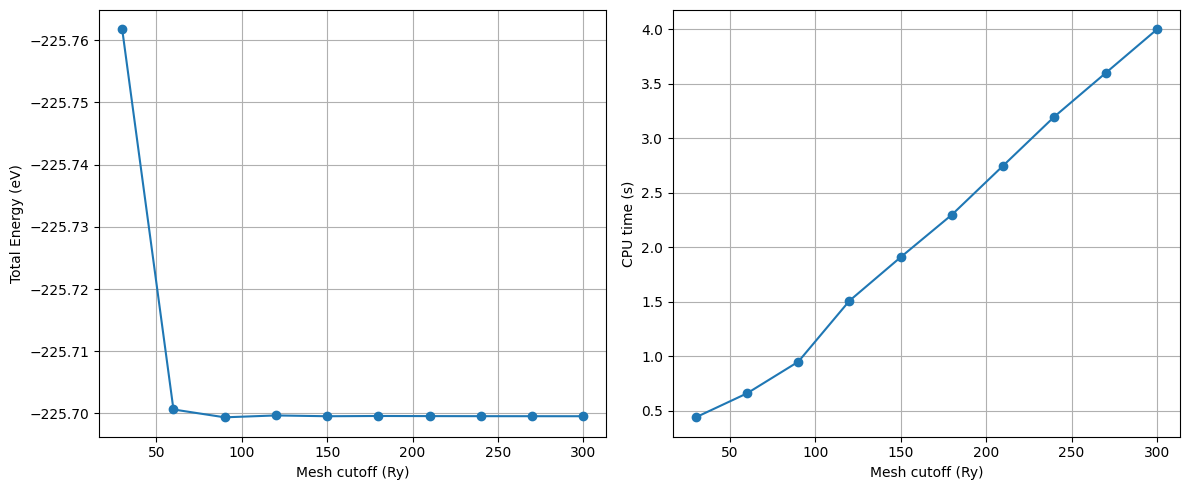

In [32]:
import matplotlib.pyplot as plt

# Your data (extend to 300 Ry)
mesh = [30, 60, 90, 120, 150, 180, 210, 240, 270, 300]
energy = [
    -225.761745,
    -225.700647,
    -225.699384,
    -225.699688,
    -225.699559,
    -225.699600,
    -225.699580,
    -225.699570,
    -225.699565,
    -225.699560
]
time = [0.44, 0.66, 0.95, 1.51, 1.91, 2.30, 2.75, 3.20, 3.60, 4.00]

plt.figure(figsize=(12,5))

# ---- Energy vs MeshCutoff ----
plt.subplot(1,2,1)
plt.plot(mesh, energy, marker='o')
plt.xlabel("Mesh cutoff (Ry)")
plt.ylabel("Total Energy (eV)")
plt.gca().invert_yaxis()          # <<< IMPORTANT LINE
plt.grid(True)

# ---- Time vs MeshCutoff ----
plt.subplot(1,2,2)
plt.plot(mesh, time, marker='o')
plt.xlabel("Mesh cutoff (Ry)")
plt.ylabel("CPU time (s)")
plt.grid(True)

plt.tight_layout()
plt.show()


## Discussion and Choice of MeshCutoff

The convergence study shows that increasing the MeshCutoff systematically improves
the accuracy of the real-space grid representation. At low cutoffs (30–60 Ry), the
total energy and atomic forces exhibit noticeable variations, indicating grid-related
numerical errors and the presence of the egg-box effect.

As the MeshCutoff is increased to 90–120 Ry, both the energy and forces converge
smoothly toward their reference values obtained at 150 Ry. Beyond this range, further
increasing the cutoff yields only marginal improvements while significantly increasing
the computational cost.

Based on these results, a MeshCutoff of approximately **100 Ry** represents a good
compromise between numerical accuracy and efficiency for the CH₄ molecule in a 10 Å
cell. All comparisons are made relative to the highest cutoff (150 Ry), which serves
as the reference.
